# Coffee & Health Dataset — Validation Review

This notebook is for **manually reviewing the generated dataset** before it's used to build the student-facing materials — not itself a teaching artifact. It checks:
1. **Data quality issues** behave as designed (duplicates, Age/BMI anomalies, demographic-differential missingness)
2. **EDA patterns** the dataset was designed to contain actually show up (country effects, dose-response smoking, non-deterministic relationships, the decaf explanation for an imperfect correlation, etc.)
3. **ML performance** on the `SelfRatedHealth` target is sane (not suspiciously perfect — which would suggest leakage — and not degenerate)

See `DATA_GENERATION_SPEC.md` and `DATA_GENERATION_ALGORITHM.md` for the full design rationale being checked against here.

## Setup

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

## 1. Load Dataset

In [2]:
# Load the dataset
df = pd.read_csv('generated_coffee_health_dataset.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head(10)

Dataset shape: (10040, 16)

Columns: ['ID', 'Country', 'Age', 'Gender', 'Smoking Status', 'Alcohol Level', 'Daily Coffees', 'Caffeine Intake', 'Stress Level', 'Physical Activity Level', 'BMI', 'Avg Resting Heart Rate', 'Avg Sleep Hours Per Night', 'Sleep Quality', 'Health Issues', 'SelfRatedHealth']


,ID,Country,Age,Gender,Smoking Status,Alcohol Level,Daily Coffees,Caffeine Intake,Stress Level,Physical Activity Level,BMI,Avg Resting Heart Rate,Avg Sleep Hours Per Night,Sleep Quality,Health Issues,SelfRatedHealth
0,1,Norway,44.0,Male,Never,Light,2.6,306.7,Low,Lightly Active,33.2,NaN,6.9,Excellent,No Issues,Very Good
1,2,Norway,32.0,Female,Light Smoker,Moderate,2.7,24.0,Low,Sedentary,26.9,89.0,NaN,Good,Mild,Good
2,3,Italy,47.0,Female,Never,Light,1.6,28.0,Low,Lightly Active,17.5,74.0,NaN,Good,Mild,Good
3,4,Norway,28.0,Female,Former,Non-Drinker,3.0,323.8,Medium,Lightly Active,23.2,80.0,7.6,Good,No Issues,Good
4,5,France,54.0,Female,Former,Light,3.9,275.9,NaN,Lightly Active,22.8,73.0,7.2,Good,Mild,Fair
5,6,UK,42.0,Female,Never,Heavy,0.7,50.0,High,Lightly Active,34.1,80.0,5.4,Fair,No Issues,Fair
6,7,UK,35.0,Female,Never,Light,0.6,37.5,Medium,Moderately Active,29.3,70.0,7.1,Excellent,No Issues,Very Good
7,8,Norway,60.0,Female,Light Smoker,Non-Drinker,3.9,378.2,Low,Moderately Active,24.2,68.0,8.2,Excellent,NaN,Good
8,9,Italy,41.0,Female,Never,Light,2.8,207.4,Low,Sedentary,29.9,75.0,7.7,Excellent,Mild,Good
9,10,Italy,50.0,Male,Former,Moderate,2.6,160.8,Medium,Sedentary,27.1,NaN,6.6,Good,Mild,Good


In [3]:
# Data types and missing values
print("=== Data Info ===")
df.info()

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10040 entries, 0 to 10039
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   ID                         10040 non-null  int64  
 1   Country                    10040 non-null  object 
 2   Age                        10038 non-null  float64
 3   Gender                     10035 non-null  object 
 4   Smoking Status             10036 non-null  object 
 5   Alcohol Level              10038 non-null  object 
 6   Daily Coffees              10036 non-null  float64
 7   Caffeine Intake            10037 non-null  float64
 8   Stress Level               9505 non-null   object 
 9   Physical Activity Level    10034 non-null  object 
 10  BMI                        10035 non-null  float64
 11  Avg Resting Heart Rate     9429 non-null   float64
 12  Avg Sleep Hours Per Night  9292 non-null   float64
 13  Sleep Quality              1

## 1.5 Data Quality Assessment

The dataset intentionally contains these data quality issues (by design, per `DATA_GENERATION_ALGORITHM.md`):
- Duplicate rows (~0.4%)
- Age anomalies — typo-style doubled-digit errors (e.g. 34 recorded as 344); fixed after v1 review so they no longer collapse to one sentinel value
- BMI anomalies — typo-style missed decimal point (e.g. 24.5 recorded as 245); added after v1 review
- Missing values — demographic-differential on `Avg Sleep Hours Per Night`, `Avg Resting Heart Rate`, `Stress Level` (rate increases with age, reflecting lower wearable/app adoption), flat on `Health Issues`, plus a handful of row-level incomplete records

Let's confirm each of these actually looks right before doing anything else.

In [4]:
# 1. Check for duplicate rows
print("=== DUPLICATE ROWS ===")
n_duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {n_duplicates} ({n_duplicates / len(df) * 100:.2f}%)")

if n_duplicates > 0:
    duplicate_rows = df[df.duplicated(keep=False)].sort_values('ID')
    display(duplicate_rows.head(6))

=== DUPLICATE ROWS ===
Number of duplicate rows: 40 (0.40%)


,ID,Country,Age,Gender,Smoking Status,Alcohol Level,Daily Coffees,Caffeine Intake,Stress Level,Physical Activity Level,BMI,Avg Resting Heart Rate,Avg Sleep Hours Per Night,Sleep Quality,Health Issues,SelfRatedHealth
527,528,Italy,54.0,Male,Never,Heavy,3.3,231.3,High,Moderately Active,29.1,59.0,5.4,Poor,No Issues,Good
10017,528,Italy,54.0,Male,Never,Heavy,3.3,231.3,High,Moderately Active,29.1,59.0,5.4,Poor,No Issues,Good
662,663,France,23.0,Male,Heavy Smoker,Light,1.9,162.0,Medium,Sedentary,21.7,93.0,7.2,Good,Moderate,Fair
10002,663,France,23.0,Male,Heavy Smoker,Light,1.9,162.0,Medium,Sedentary,21.7,93.0,7.2,Good,Moderate,Fair
979,980,France,27.0,Female,Light Smoker,Moderate,2.7,186.4,Medium,Sedentary,21.6,74.0,6.3,Fair,NaN,Good
10014,980,France,27.0,Female,Light Smoker,Moderate,2.7,186.4,Medium,Sedentary,21.6,74.0,6.3,Fair,NaN,Good


=== AGE ANOMALIES ===
Ages outside normal adult range: 72 (0.72%)
count     72.000000
mean     416.708333
std      123.874475
min      199.000000
25%      322.000000
50%      411.000000
75%      524.750000
max      666.000000
Name: Age, dtype: float64

Distinct anomalous values: 39 (should be >1 -- no sentinel collapse)
Recovered ages all in plausible adult range (13-100): True


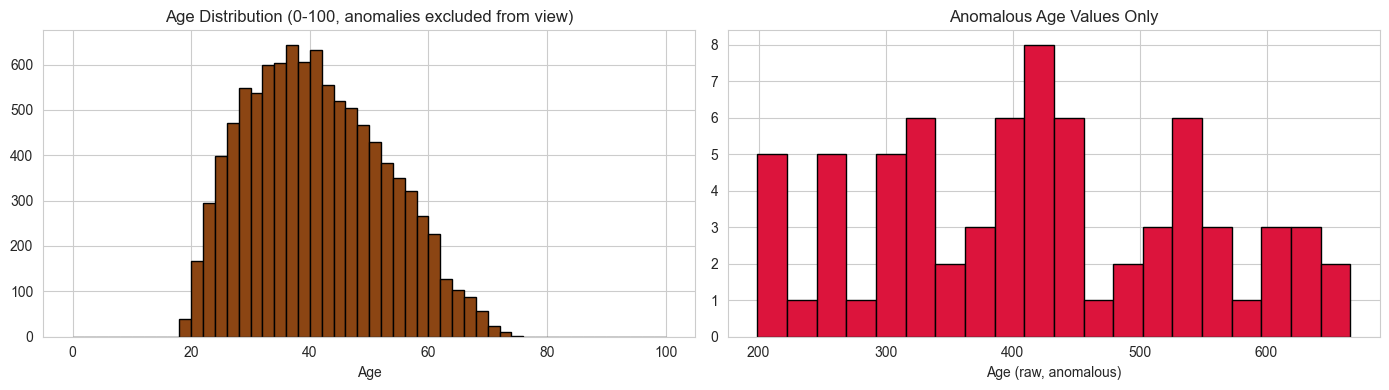

In [5]:
# 2. Check for Age anomalies (typo-style errors)
print("=== AGE ANOMALIES ===")
age_anomalies = df[(df['Age'] > 100) | (df['Age'] < 13)]
print(f"Ages outside normal adult range: {len(age_anomalies)} ({len(age_anomalies) / len(df) * 100:.2f}%)")
print(age_anomalies['Age'].describe())

# Confirm the "reason about it" property: each anomaly should be exactly recoverable
# by stripping the trailing digit (no more collapsing to a single sentinel value).
recovered = age_anomalies['Age'].apply(lambda a: int(str(int(a))[:-1]))
print(f"\nDistinct anomalous values: {age_anomalies['Age'].nunique()} (should be >1 -- no sentinel collapse)")
print(f"Recovered ages all in plausible adult range (13-100): {recovered.between(13, 100).all()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['Age'].dropna(), bins=50, range=(0, 100), color='saddlebrown', edgecolor='black')
axes[0].set_title('Age Distribution (0-100, anomalies excluded from view)')
axes[0].set_xlabel('Age')

axes[1].hist(age_anomalies['Age'], bins=20, color='crimson', edgecolor='black')
axes[1].set_title('Anomalous Age Values Only')
axes[1].set_xlabel('Age (raw, anomalous)')

plt.tight_layout()
plt.show()

=== BMI ANOMALIES ===
BMI values outside plausible range (>60): 56 (0.56%)
count     56.000000
mean     262.642857
std       38.570091
min      182.000000
25%      238.750000
50%      256.000000
75%      286.000000
max      389.000000
Name: BMI, dtype: float64

Recovered BMI all in plausible range (16-45): True


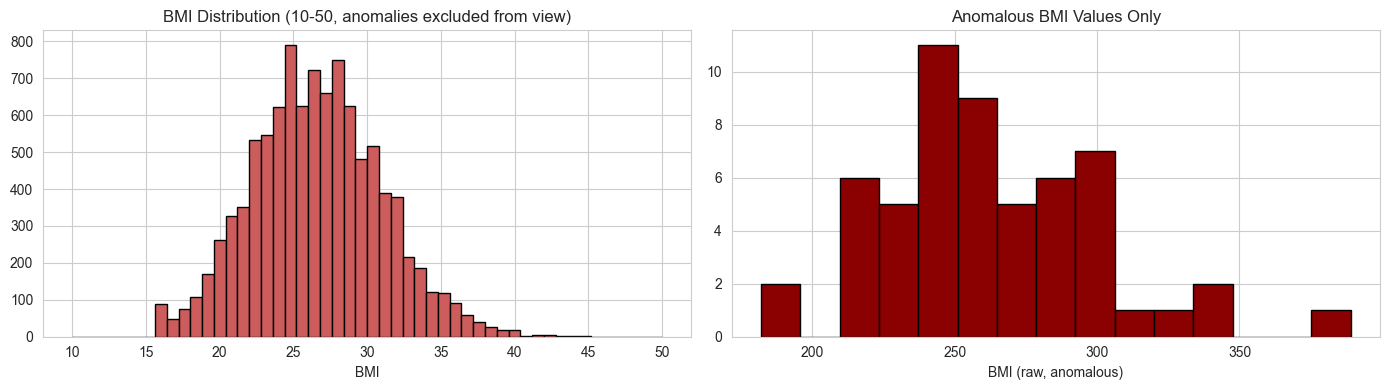

In [6]:
# 2b. Check for BMI anomalies (missed-decimal-point errors)
print("=== BMI ANOMALIES ===")
bmi_anomalies = df[df['BMI'] > 60]
print(f"BMI values outside plausible range (>60): {len(bmi_anomalies)} ({len(bmi_anomalies) / len(df) * 100:.2f}%)")
print(bmi_anomalies['BMI'].describe())

# Should be exactly recoverable by dividing by 10
recovered_bmi = (bmi_anomalies['BMI'] / 10).round(1)
print(f"\nRecovered BMI all in plausible range (16-45): {recovered_bmi.between(16, 45).all()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df['BMI'].dropna(), bins=50, range=(10, 50), color='indianred', edgecolor='black')
axes[0].set_title('BMI Distribution (10-50, anomalies excluded from view)')
axes[0].set_xlabel('BMI')

axes[1].hist(bmi_anomalies['BMI'], bins=15, color='darkred', edgecolor='black')
axes[1].set_title('Anomalous BMI Values Only')
axes[1].set_xlabel('BMI (raw, anomalous)')

plt.tight_layout()
plt.show()

In [7]:
# 3. Missing values analysis
print("=== MISSING VALUES ANALYSIS ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'missing': missing, 'pct': missing_pct}))

# Row-level: how many missing values per row?
missing_per_row = df.isnull().sum(axis=1)
print(f"\nRows with 4+ missing values (likely incomplete records): {(missing_per_row >= 4).sum()}")

=== MISSING VALUES ANALYSIS ===
                           missing    pct
ID                               0   0.00
Country                          0   0.00
Age                              2   0.02
Gender                           5   0.05
Smoking Status                   4   0.04
Alcohol Level                    2   0.02
Daily Coffees                    4   0.04
Caffeine Intake                  3   0.03
Stress Level                   535   5.33
Physical Activity Level          6   0.06
BMI                              5   0.05
Avg Resting Heart Rate         611   6.09
Avg Sleep Hours Per Night      748   7.45
Sleep Quality                    3   0.03
Health Issues                 1047  10.43
SelfRatedHealth                  0   0.00

Rows with 4+ missing values (likely incomplete records): 10


### Missing Values by Demographic Group

The whole-population missingness rates above hide the actual design: `Avg Sleep Hours Per Night`, `Avg Resting Heart Rate`, and `Stress Level` were deliberately given **age-differential** missingness (older = less likely to have a wearable/app logging these), while `Health Issues` was deliberately kept **flat**. Slicing by Age band, Gender, and Country should confirm that — a real pattern on the first three, no pattern on `Health Issues` or across Gender/Country.

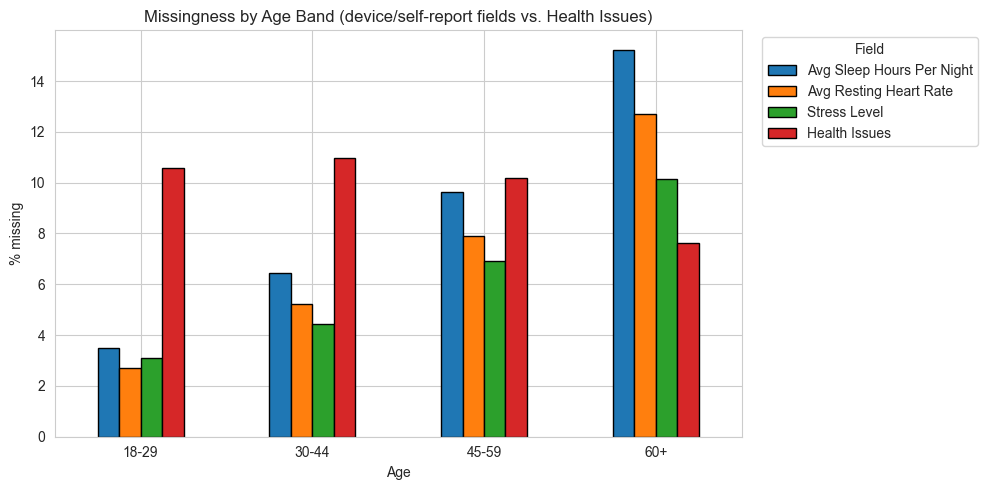

,Avg Sleep Hours Per Night,Avg Resting Heart Rate,Stress Level,Health Issues
Age,,,,
18-29,3.5,2.7,3.1,10.6
30-44,6.4,5.2,4.4,11.0
45-59,9.6,7.9,6.9,10.2
60+,15.2,12.7,10.2,7.6


In [8]:
# Missing values by Age band
device_cols = ['Avg Sleep Hours Per Night', 'Avg Resting Heart Rate', 'Stress Level']
age_bands = pd.cut(df['Age'], bins=[0, 29, 44, 59, 999], labels=['18-29', '30-44', '45-59', '60+'])
missing_by_age = df.groupby(age_bands, observed=True)[device_cols + ['Health Issues']].apply(
    lambda g: g.isnull().mean() * 100
)

missing_by_age.plot(kind='bar', figsize=(10, 5), edgecolor='black')
plt.ylabel('% missing')
plt.title('Missingness by Age Band (device/self-report fields vs. Health Issues)')
plt.xticks(rotation=0)
plt.legend(title='Field', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

missing_by_age.round(1)

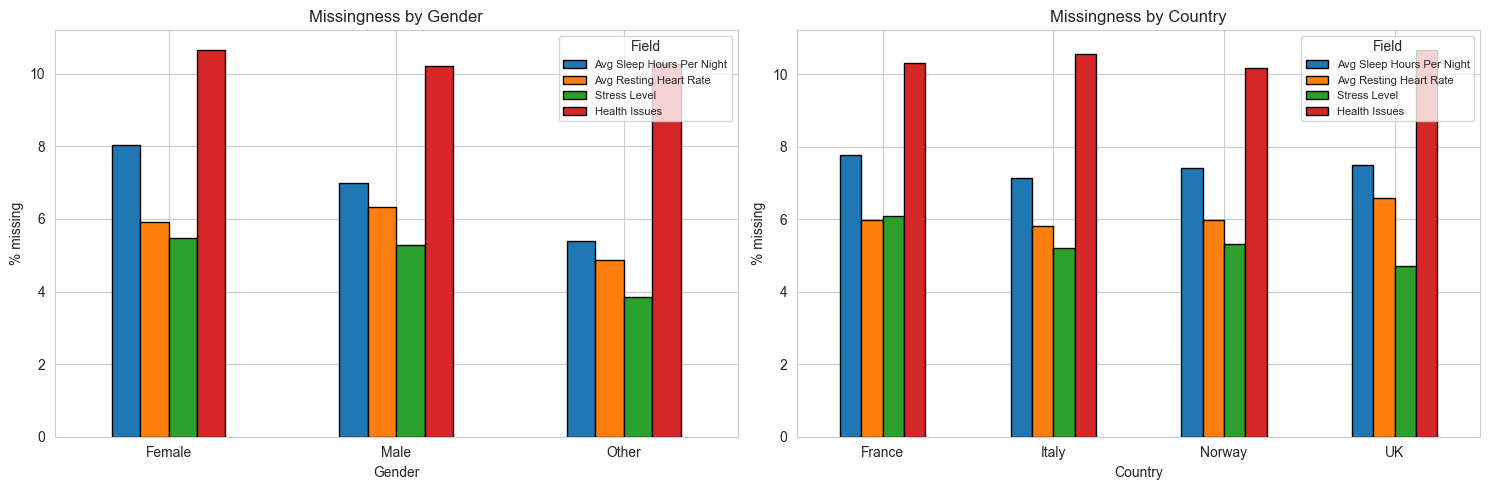

Gender:
        Avg Sleep Hours Per Night  Avg Resting Heart Rate  Stress Level  \
Gender                                                                    
Female                        8.0                     5.9           5.5   
Male                          7.0                     6.3           5.3   
Other                         5.4                     4.9           3.8   

        Health Issues  
Gender                 
Female           10.7  
Male             10.2  
Other            10.3  

Country:
         Avg Sleep Hours Per Night  Avg Resting Heart Rate  Stress Level  \
Country                                                                    
France                         7.8                     6.0           6.1   
Italy                          7.1                     5.8           5.2   
Norway                         7.4                     6.0           5.3   
UK                             7.5                     6.6           4.7   

         Health Issues  
Coun

In [9]:
# Missing values by Gender and Country -- should NOT show a strong pattern
# (the differential design was Age-only), which is itself worth confirming
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

missing_by_gender = df.groupby('Gender')[device_cols + ['Health Issues']].apply(lambda g: g.isnull().mean() * 100)
missing_by_gender.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_ylabel('% missing')
axes[0].set_title('Missingness by Gender')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Field', fontsize=8)

missing_by_country = df.groupby('Country')[device_cols + ['Health Issues']].apply(lambda g: g.isnull().mean() * 100)
missing_by_country.plot(kind='bar', ax=axes[1], edgecolor='black')
axes[1].set_ylabel('% missing')
axes[1].set_title('Missingness by Country')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Field', fontsize=8)

plt.tight_layout()
plt.show()

print("Gender:")
print(missing_by_gender.round(1))
print("\nCountry:")
print(missing_by_country.round(1))

### Data Cleaning

Based on the assessment above:

1. **Duplicates**: drop exact duplicate rows (keep first occurrence)
2. **Age anomalies**: typo-style doubled-digit errors (e.g. 34 recorded as 344). Stripping the last digit exactly recovers the original age — confirmed above that these no longer collapse to a single sentinel value
3. **BMI anomalies**: typo-style missed decimal point (e.g. 24.5 recorded as 245). Dividing by 10 exactly recovers the original value
4. **Missing values**: drop the handful of rows with many missing fields (likely corrupted records), then impute the remaining feature-level missingness — numeric fields (`Avg Sleep Hours Per Night`, `Avg Resting Heart Rate`) with the **country median** (these vary by country, so a global median would be a worse estimate), categorical fields (`Stress Level`, `Health Issues`) with the mode

In [10]:
# Create cleaned dataset
df_clean = df.copy()

print("=== DATA CLEANING PROCESS ===\n")

# 1. Remove duplicates
n_before = len(df_clean)
df_clean = df_clean.drop_duplicates()
print(f"1. Duplicates removed: {n_before - len(df_clean)} rows ({len(df_clean)} remaining)")

# 2. Fix Age anomalies (strip the doubled trailing digit)
def fix_age(age):
    if pd.isna(age) or age <= 100:
        return age
    fixed = int(str(int(age))[:-1])
    return fixed if 13 <= fixed <= 100 else np.nan

n_age_anomalies_before = (df_clean['Age'] > 100).sum()
df_clean['Age'] = df_clean['Age'].apply(fix_age)
print(f"2. Age anomalies fixed: {n_age_anomalies_before} values corrected")

# 3. Fix BMI anomalies (undo the missed decimal point)
n_bmi_anomalies_before = (df_clean['BMI'] > 60).sum()
df_clean.loc[df_clean['BMI'] > 60, 'BMI'] = (df_clean.loc[df_clean['BMI'] > 60, 'BMI'] / 10).round(1)
print(f"3. BMI anomalies fixed: {n_bmi_anomalies_before} values corrected")

# 4a. Drop rows with many missing values (likely corrupted records)
missing_per_row = df_clean.isnull().sum(axis=1)
n_before = len(df_clean)
df_clean = df_clean[missing_per_row < 4]
print(f"4a. Incomplete rows dropped (4+ missing fields): {n_before - len(df_clean)} rows")

# 4b. Impute remaining feature-level missingness
for col in ['Avg Sleep Hours Per Night', 'Avg Resting Heart Rate']:
    df_clean[col] = df_clean.groupby('Country')[col].transform(lambda s: s.fillna(s.median()))
for col in ['Stress Level', 'Health Issues']:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
# Any other stray missing values (rare, from the row-level corruption pattern): drop
n_before = len(df_clean)
df_clean = df_clean.dropna()
print(f"4b. Remaining missing values imputed/dropped: {n_before - len(df_clean)} residual rows dropped")

print(f"\nFinal cleaned shape: {df_clean.shape}")
print(f"Remaining missing values: {df_clean.isnull().sum().sum()}")

=== DATA CLEANING PROCESS ===

1. Duplicates removed: 40 rows (10000 remaining)
2. Age anomalies fixed: 71 values corrected
3. BMI anomalies fixed: 56 values corrected
4a. Incomplete rows dropped (4+ missing fields): 10 rows
4b. Remaining missing values imputed/dropped: 0 residual rows dropped

Final cleaned shape: (9990, 16)
Remaining missing values: 0


## 2. Exploratory Data Analysis (EDA)

All EDA from here uses `df_clean`.

### 2.1 Descriptive Statistics

In [11]:
# Numerical features summary
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,9990.0,5000.226026,2887.132736,1.0,2500.25,4998.5,7500.75,10000.0
Age,9990.0,40.690991,11.516310,18.0,32.00,40.0,49.00,74.0
Daily Coffees,9990.0,2.591672,1.120119,0.0,1.80,2.6,3.30,6.5
Caffeine Intake,9990.0,196.823704,123.869333,0.0,107.95,180.1,265.10,750.0
BMI,9990.0,26.592743,4.415721,16.0,23.50,26.4,29.50,45.0
Avg Resting Heart Rate,9990.0,75.707808,7.942632,45.0,71.00,76.0,81.00,110.0
Avg Sleep Hours Per Night,9990.0,6.383123,1.025439,3.0,5.70,6.4,7.00,10.5


In [12]:
# Categorical features summary
categorical_cols = ['Country', 'Gender', 'Smoking Status', 'Alcohol Level',
                     'Physical Activity Level', 'Stress Level', 'Sleep Quality',
                     'Health Issues', 'SelfRatedHealth']

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(df_clean[col].value_counts(normalize=True).mul(100).round(1))


--- Country ---
Country
Norway    25.0
Italy     25.0
France    25.0
UK        25.0
Name: proportion, dtype: float64

--- Gender ---
Gender
Female    48.1
Male      48.0
Other      3.9
Name: proportion, dtype: float64

--- Smoking Status ---
Smoking Status
Never           58.2
Former          20.3
Light Smoker    13.9
Heavy Smoker     7.6
Name: proportion, dtype: float64

--- Alcohol Level ---
Alcohol Level
Moderate       35.0
Light          34.7
Heavy          15.3
Non-Drinker    15.0
Name: proportion, dtype: float64

--- Physical Activity Level ---
Physical Activity Level
Lightly Active       29.0
Moderately Active    28.0
Sedentary            26.8
Very Active          16.2
Name: proportion, dtype: float64

--- Stress Level ---
Stress Level
Low       47.2
Medium    33.6
High      19.2
Name: proportion, dtype: float64

--- Sleep Quality ---
Sleep Quality
Good         45.0
Fair         25.0
Excellent    20.0
Poor         10.0
Name: proportion, dtype: float64

--- Health Issues ---
Hea

### 2.2 Distribution Visualizations

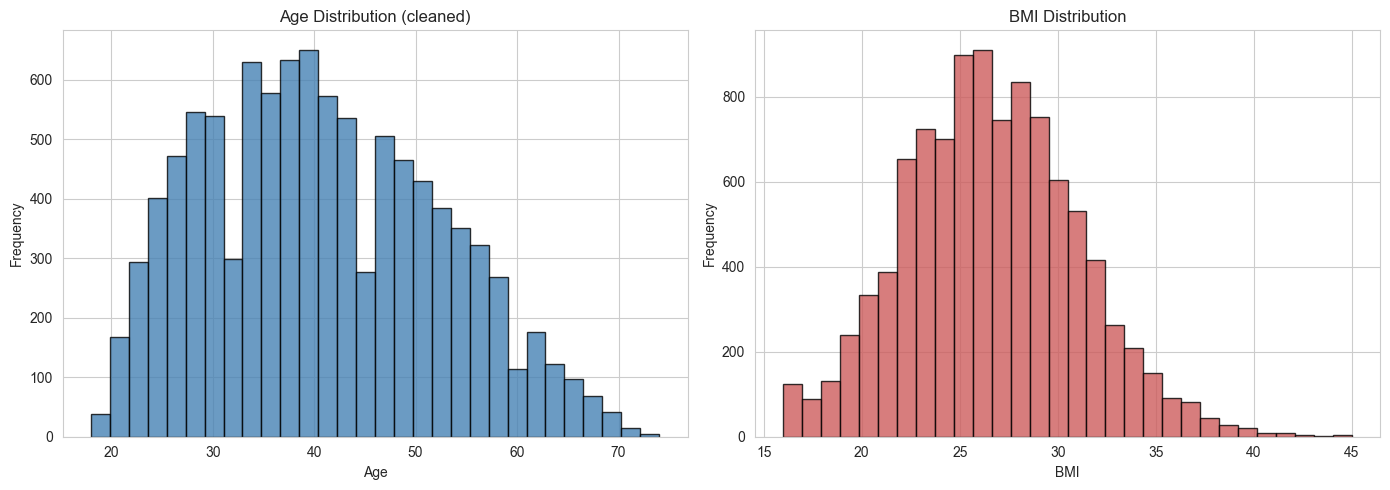

In [13]:
# Age and BMI distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['Age'], bins=30, edgecolor='black', alpha=0.8, color='steelblue')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Age Distribution (cleaned)')

axes[1].hist(df_clean['BMI'], bins=30, edgecolor='black', alpha=0.8, color='indianred')
axes[1].set_xlabel('BMI')
axes[1].set_ylabel('Frequency')
axes[1].set_title('BMI Distribution')

plt.tight_layout()
plt.show()

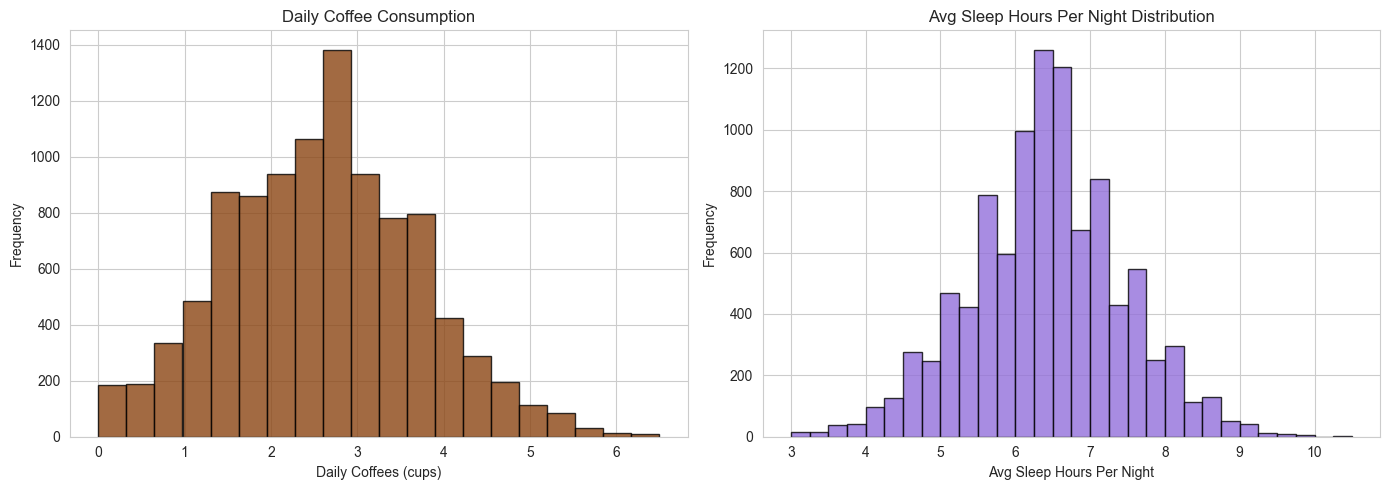

In [14]:
# Coffee & sleep distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['Daily Coffees'], bins=20, edgecolor='black', alpha=0.8, color='saddlebrown')
axes[0].set_xlabel('Daily Coffees (cups)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Daily Coffee Consumption')

axes[1].hist(df_clean['Avg Sleep Hours Per Night'], bins=30, edgecolor='black', alpha=0.8, color='mediumpurple')
axes[1].set_xlabel('Avg Sleep Hours Per Night')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Avg Sleep Hours Per Night Distribution')

plt.tight_layout()
plt.show()

### 2.3 Categorical Variable Distributions

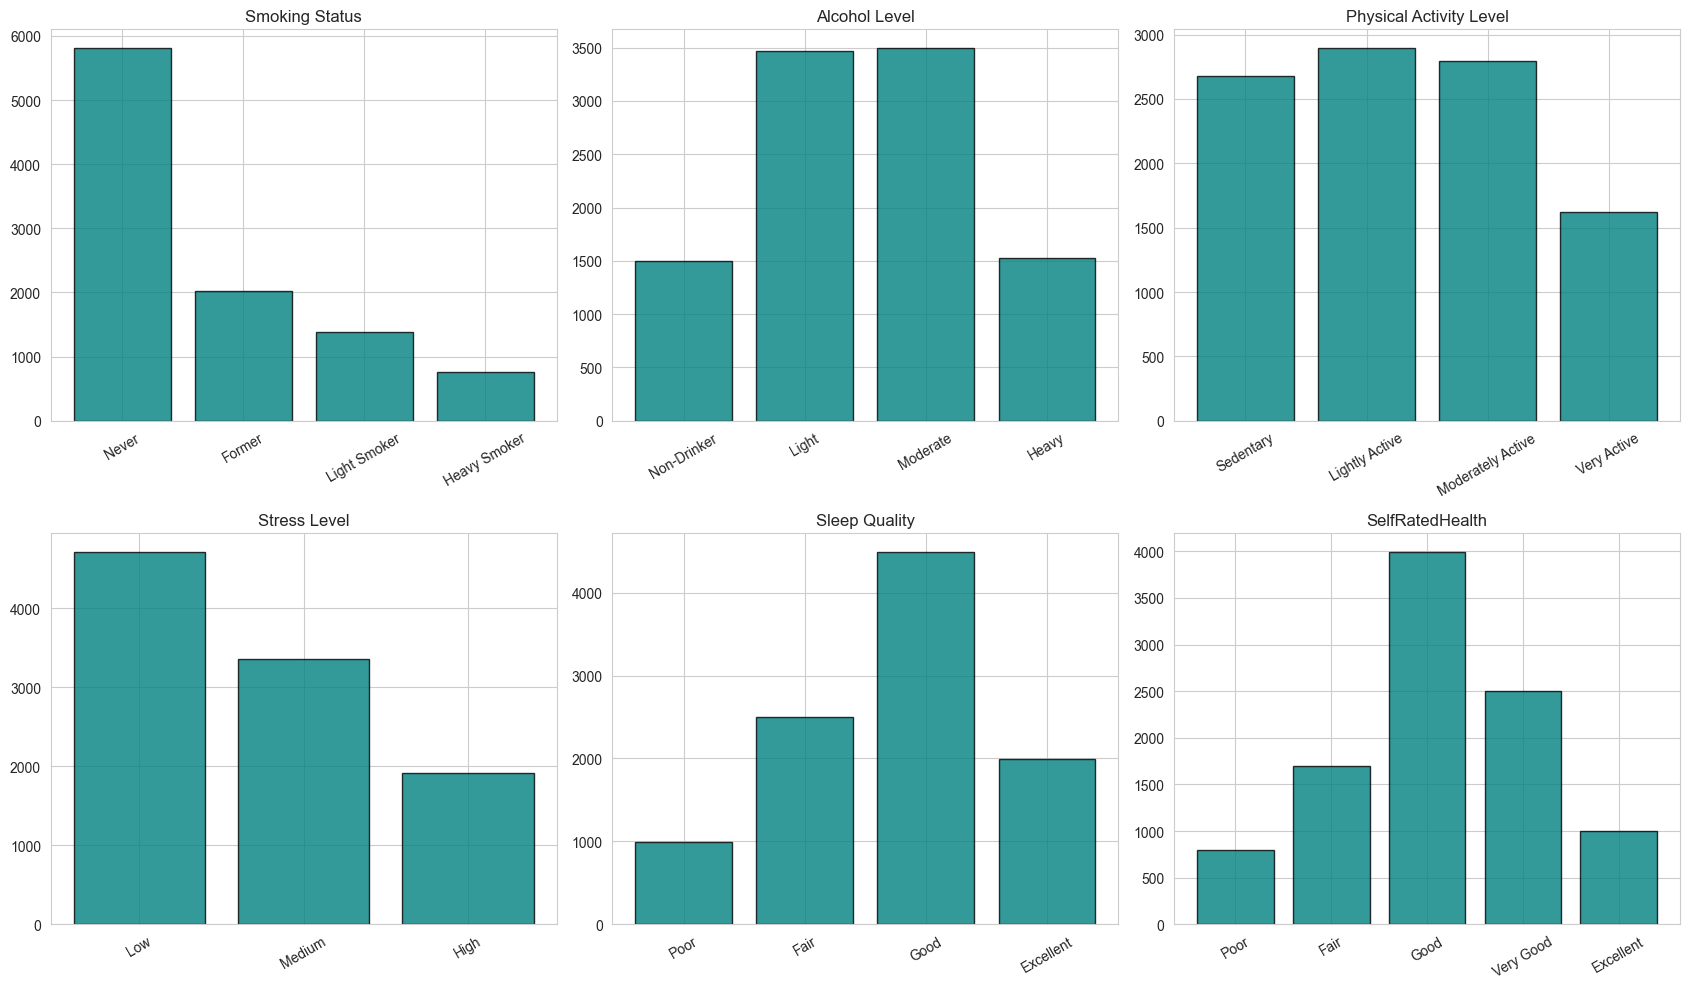

In [15]:
# Ordered categorical distributions (plotting in their natural order, not alphabetical)
orders = {
    'Smoking Status': ['Never', 'Former', 'Light Smoker', 'Heavy Smoker'],
    'Alcohol Level': ['Non-Drinker', 'Light', 'Moderate', 'Heavy'],
    'Physical Activity Level': ['Sedentary', 'Lightly Active', 'Moderately Active', 'Very Active'],
    'Stress Level': ['Low', 'Medium', 'High'],
    'Sleep Quality': ['Poor', 'Fair', 'Good', 'Excellent'],
    'SelfRatedHealth': ['Poor', 'Fair', 'Good', 'Very Good', 'Excellent'],
}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (col, order) in zip(axes.flat, orders.items()):
    counts = df_clean[col].value_counts().reindex(order)
    ax.bar(order, counts.values, color='teal', edgecolor='black', alpha=0.8)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 2.4 Correlation Analysis

Numeric features plus the ordinal categorical features (encoded 0, 1, 2, ... in their natural order) so relationships like "more stress → worse sleep quality" show up as a correlation, not just a crosstab.

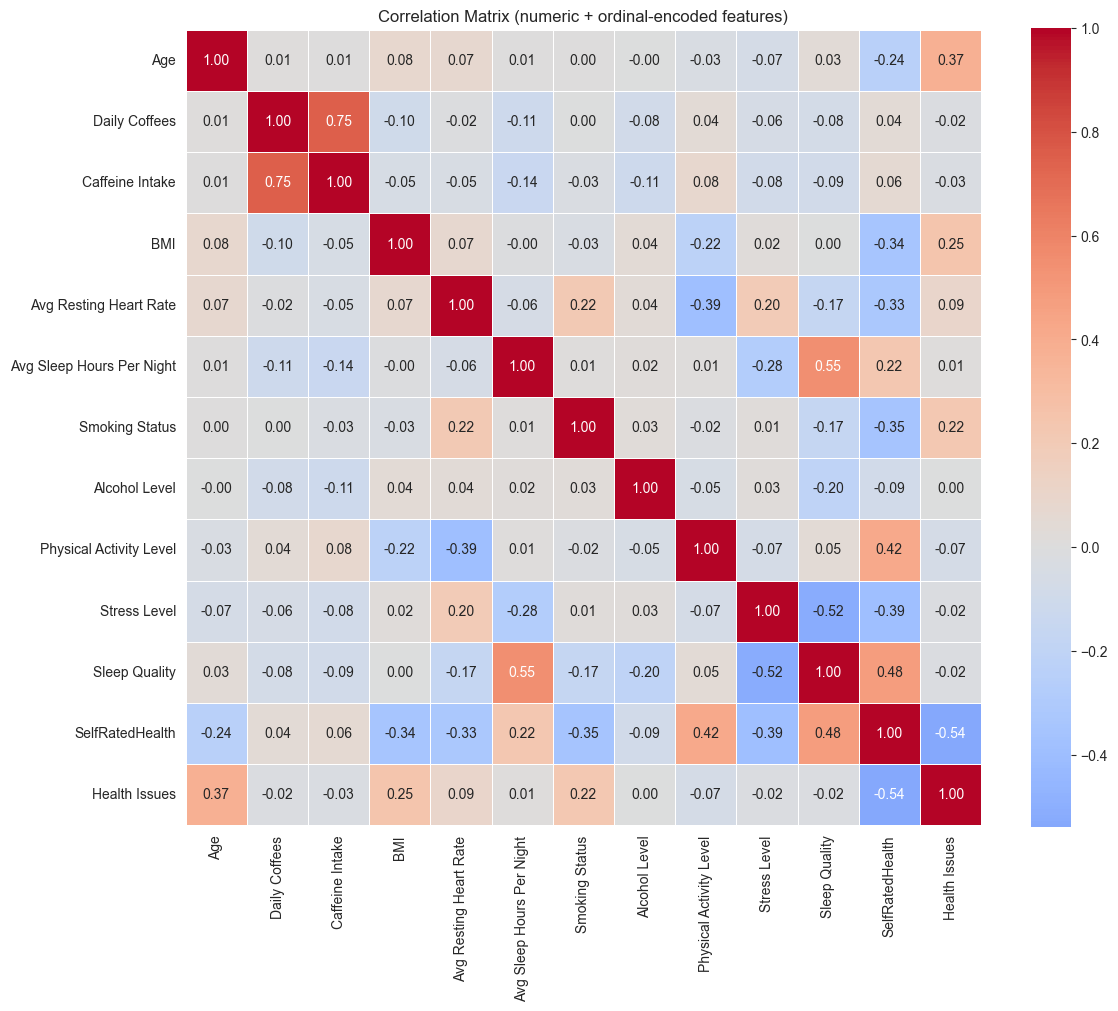

In [16]:
# Build an ordinal-encoded copy for correlation purposes
ordinal_orders = {**orders, 'Health Issues': ['No Issues', 'Mild', 'Moderate', 'Severe']}

df_corr = df_clean.copy()
for col, order in ordinal_orders.items():
    df_corr[col] = df_corr[col].map({v: i for i, v in enumerate(order)})

corr_cols = ['Age', 'Daily Coffees', 'Caffeine Intake', 'BMI', 'Avg Resting Heart Rate',
             'Avg Sleep Hours Per Night'] + list(ordinal_orders.keys())
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix (numeric + ordinal-encoded features)')
plt.tight_layout()
plt.show()

**Daily Coffees ↔ Caffeine Intake context**: the correlation matrix above should show this pair as strong but clearly not 1.0. That's deliberate, not just noise — ~10% of people are decaf/half-caf leaning by design (see `DATA_GENERATION_ALGORITHM.md`), so they still register normal "coffees" counts but with much lower actual caffeine. Confirming that explanation, not just the correlation number, below.

corr(Daily Coffees, Caffeine Intake) = 0.749


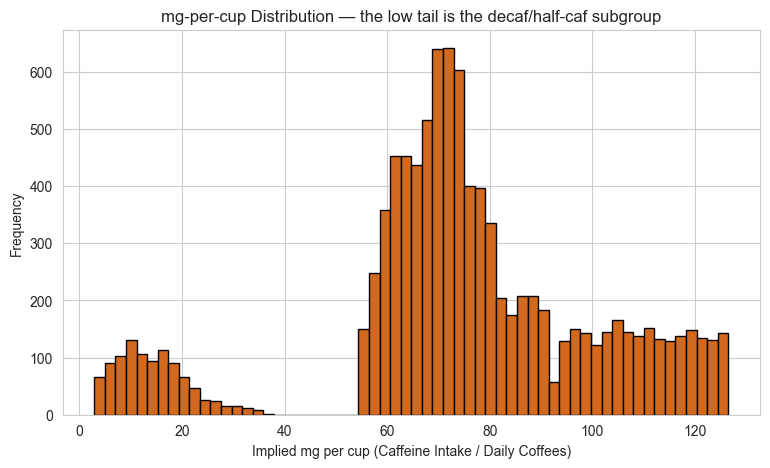

Rows with implied mg/cup < 30 (decaf-leaning): 9.8% (~10% expected by design)


In [17]:
# Confirm the decaf explanation by looking at the implied mg-per-cup ratio
d = df_clean[df_clean['Daily Coffees'] > 0].copy()
d['mg_per_cup'] = d['Caffeine Intake'] / d['Daily Coffees']

print(f"corr(Daily Coffees, Caffeine Intake) = {df_clean['Daily Coffees'].corr(df_clean['Caffeine Intake']):.3f}")

plt.figure(figsize=(9, 5))
plt.hist(d['mg_per_cup'], bins=60, color='chocolate', edgecolor='black')
plt.xlabel('Implied mg per cup (Caffeine Intake / Daily Coffees)')
plt.ylabel('Frequency')
plt.title('mg-per-cup Distribution — the low tail is the decaf/half-caf subgroup')
plt.show()

low_ratio_pct = (d['mg_per_cup'] < 30).mean() * 100
print(f"Rows with implied mg/cup < 30 (decaf-leaning): {low_ratio_pct:.1f}% (~10% expected by design)")

### 2.5 Country Comparison

This dataset was built around real coffee-consumption and health statistics for Italy, France, the UK, and Norway. Let's see whether those patterns come through in the data — and whether "more coffee" naively predicts "better health" (it shouldn't: Norway and Italy both drink a lot of coffee *and* have good health outcomes, while the UK drinks the least coffee but has the worst outcomes — lifestyle, not coffee itself, drives the difference).

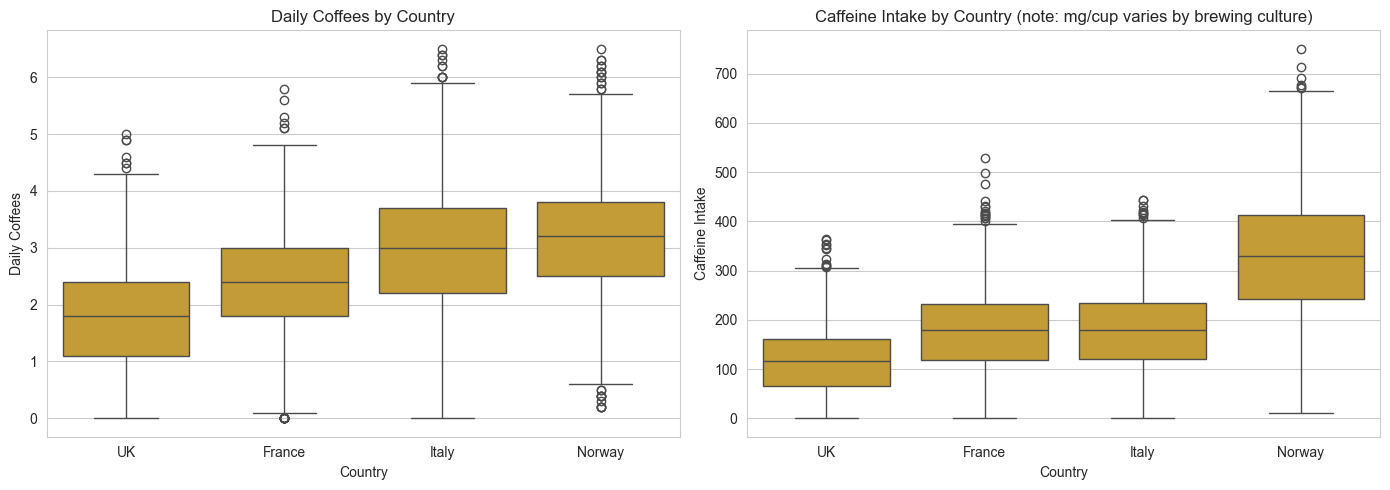

In [18]:
# Coffee consumption by country
country_order = ['UK', 'France', 'Italy', 'Norway']  # ascending real-world coffee consumption

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_clean, x='Country', y='Daily Coffees', order=country_order, ax=axes[0], color='goldenrod')
axes[0].set_title('Daily Coffees by Country')

sns.boxplot(data=df_clean, x='Country', y='Caffeine Intake', order=country_order, ax=axes[1], color='goldenrod')
axes[1].set_title('Caffeine Intake by Country (note: mg/cup varies by brewing culture)')

plt.tight_layout()
plt.show()

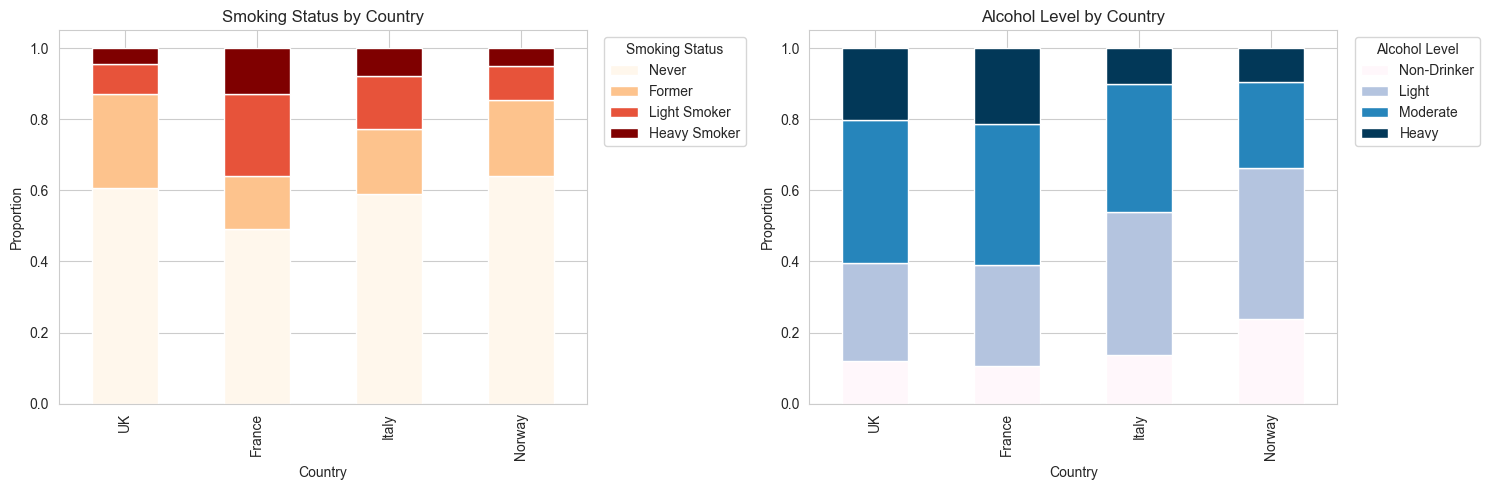

In [19]:
# Smoking and alcohol profiles by country
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

smoking_ct = pd.crosstab(df_clean['Country'], df_clean['Smoking Status'], normalize='index')[orders['Smoking Status']]
smoking_ct.loc[country_order].plot(kind='bar', stacked=True, ax=axes[0], colormap='OrRd')
axes[0].set_title('Smoking Status by Country')
axes[0].set_ylabel('Proportion')
axes[0].legend(title='Smoking Status', bbox_to_anchor=(1.02, 1), loc='upper left')

alcohol_ct = pd.crosstab(df_clean['Country'], df_clean['Alcohol Level'], normalize='index')[orders['Alcohol Level']]
alcohol_ct.loc[country_order].plot(kind='bar', stacked=True, ax=axes[1], colormap='PuBu')
axes[1].set_title('Alcohol Level by Country')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Alcohol Level', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

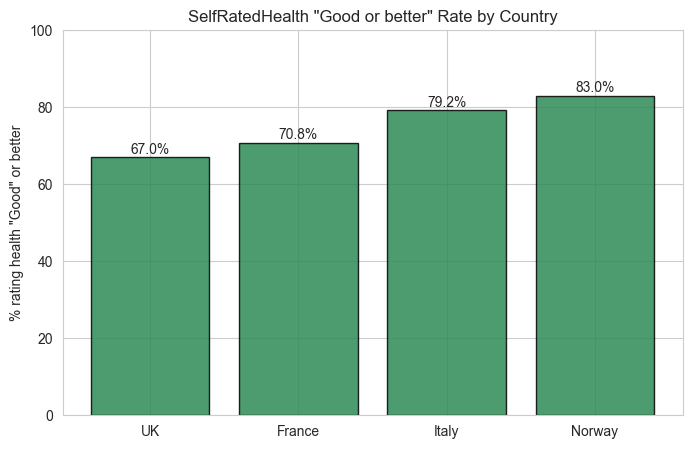

Real-world reference points these were designed around:
Norway ~80%, Italy 75.5%, France 68.5%, UK ~65% (see DATA_GENERATION_SPEC.md)


In [20]:
# SelfRatedHealth "good or better" rate by country
good_plus = df_clean['SelfRatedHealth'].isin(['Good', 'Very Good', 'Excellent'])
good_plus_rate = good_plus.groupby(df_clean['Country']).mean().reindex(country_order) * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(good_plus_rate.index, good_plus_rate.values, color='seagreen', edgecolor='black', alpha=0.85)
plt.ylabel('% rating health "Good" or better')
plt.title('SelfRatedHealth "Good or better" Rate by Country')
plt.ylim(0, 100)
for bar, val in zip(bars, good_plus_rate.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val:.1f}%', ha='center')
plt.show()

print("Real-world reference points these were designed around:")
print("Norway ~80%, Italy 75.5%, France 68.5%, UK ~65% (see DATA_GENERATION_SPEC.md)")

### 2.6 Relationship Analysis

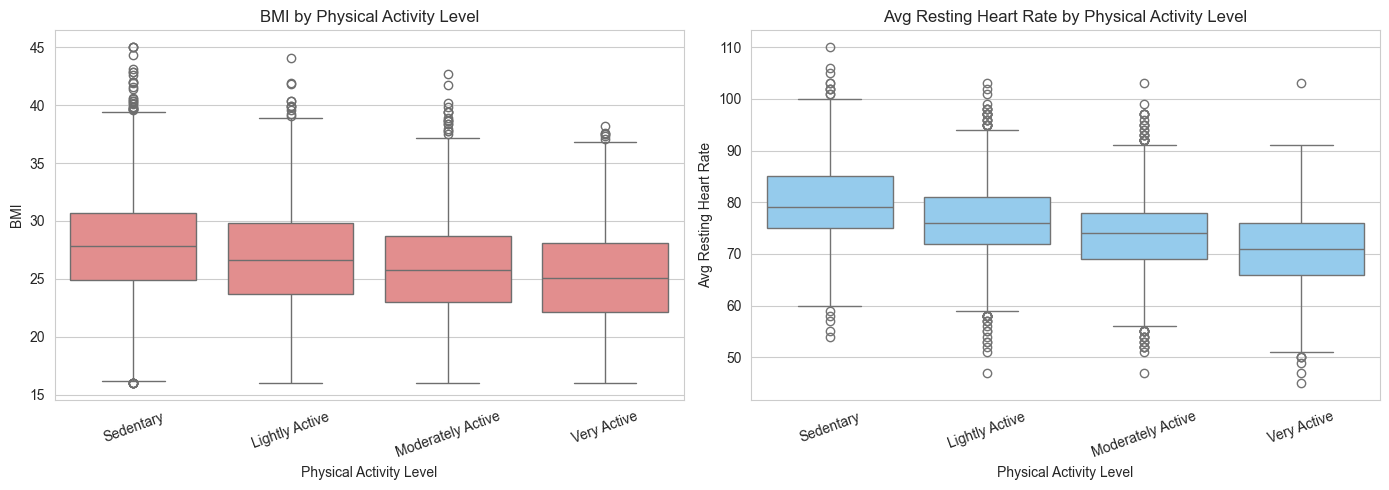

In [21]:
# Physical Activity Level vs BMI and Avg Resting Heart Rate
activity_order = orders['Physical Activity Level']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df_clean, x='Physical Activity Level', y='BMI', order=activity_order, ax=axes[0], color='lightcoral')
axes[0].set_title('BMI by Physical Activity Level')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=df_clean, x='Physical Activity Level', y='Avg Resting Heart Rate', order=activity_order, ax=axes[1], color='lightskyblue')
axes[1].set_title('Avg Resting Heart Rate by Physical Activity Level')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

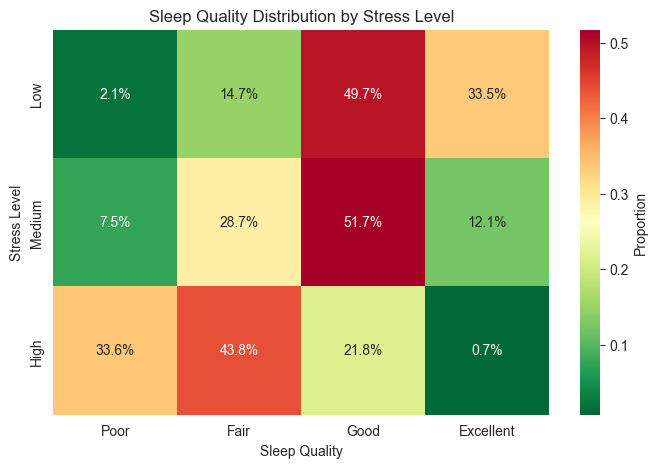

In [22]:
# Sleep Quality vs Stress Level (the original dataset's core flaw was that Sleep Quality
# depended on Sleep Hours alone -- here it should visibly respond to Stress too)
stress_sleep_ct = pd.crosstab(df_clean['Stress Level'], df_clean['Sleep Quality'], normalize='index')
stress_sleep_ct = stress_sleep_ct.reindex(index=orders['Stress Level'], columns=orders['Sleep Quality'])

plt.figure(figsize=(8, 5))
sns.heatmap(stress_sleep_ct, annot=True, fmt='.1%', cmap='RdYlGn_r', cbar_kws={'label': 'Proportion'})
plt.title('Sleep Quality Distribution by Stress Level')
plt.show()

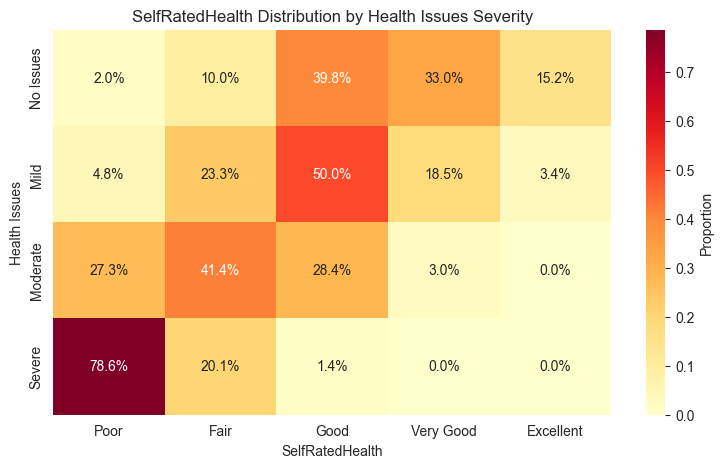

In [23]:
# Health Issues vs SelfRatedHealth -- the strongest expected predictor. Not deterministic
# (unlike the original dataset's Stress Level <-> Sleep Quality relationship, which was
# a 100% deterministic lookup with zero independent signal)
health_srh_ct = pd.crosstab(df_clean['Health Issues'], df_clean['SelfRatedHealth'], normalize='index')
health_srh_ct = health_srh_ct.reindex(index=ordinal_orders['Health Issues'], columns=orders['SelfRatedHealth'])

plt.figure(figsize=(9, 5))
sns.heatmap(health_srh_ct, annot=True, fmt='.1%', cmap='YlOrRd', cbar_kws={'label': 'Proportion'})
plt.title('SelfRatedHealth Distribution by Health Issues Severity')
plt.show()

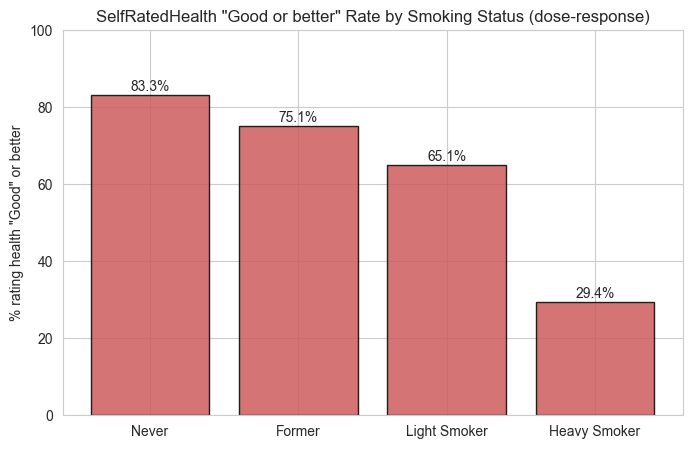

In [24]:
# Smoking dose-response: does intensity matter, not just yes/no?
smoking_good_plus = good_plus.groupby(df_clean['Smoking Status']).mean().reindex(orders['Smoking Status']) * 100

plt.figure(figsize=(8, 5))
bars = plt.bar(smoking_good_plus.index, smoking_good_plus.values, color='indianred', edgecolor='black', alpha=0.85)
plt.ylabel('% rating health "Good" or better')
plt.title('SelfRatedHealth "Good or better" Rate by Smoking Status (dose-response)')
plt.ylim(0, 100)
for bar, val in zip(bars, smoking_good_plus.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val:.1f}%', ha='center')
plt.show()

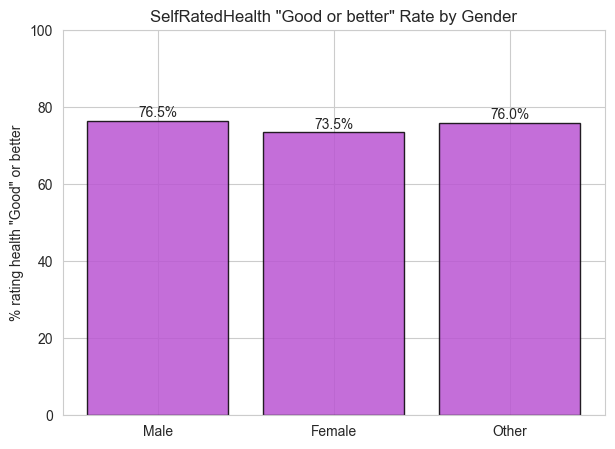

In [25]:
# The gender-health paradox: women tend to self-report lower health despite typically
# greater longevity in real epidemiological data. Does it show up here?
gender_good_plus = good_plus.groupby(df_clean['Gender']).mean().reindex(['Male', 'Female', 'Other']) * 100

plt.figure(figsize=(7, 5))
bars = plt.bar(gender_good_plus.index, gender_good_plus.values, color='mediumorchid', edgecolor='black', alpha=0.85)
plt.ylabel('% rating health "Good" or better')
plt.title('SelfRatedHealth "Good or better" Rate by Gender')
plt.ylim(0, 100)
for bar, val in zip(bars, gender_good_plus.values):
    plt.text(bar.get_x() + bar.get_width() / 2, val + 1, f'{val:.1f}%', ha='center')
plt.show()

## 3. Machine Learning — Predicting SelfRatedHealth

`SelfRatedHealth` is the dataset's single target: an ordinal 5-class outcome (`Poor` < `Fair` < `Good` < `Very Good` < `Excellent`) built from a weighted combination of Health Issues, BMI, Sleep Quality, Physical Activity, Smoking, Stress, Age, Country, and Gender — no single feature determines it, so this is a genuine multi-factorial prediction task (see `DATA_GENERATION_SPEC.md`).

### 3.1 Feature Engineering

Two kinds of categorical features need different treatment:
- **Ordinal** (Smoking Status, Alcohol Level, Physical Activity Level, Stress Level, Sleep Quality, Health Issues): encoded 0, 1, 2, ... in their natural order, since the order itself is meaningful information a tree model can split on sensibly.
- **Nominal** (Country, Gender): one-hot encoded, since there's no inherent order.

In [26]:
# Build the feature matrix
feature_ordinal_cols = ['Smoking Status', 'Alcohol Level', 'Physical Activity Level',
                         'Stress Level', 'Sleep Quality', 'Health Issues']

df_ml = df_clean.copy()
for col in feature_ordinal_cols:
    order = ordinal_orders[col]
    df_ml[col] = df_ml[col].map({v: i for i, v in enumerate(order)})

# One-hot encode nominal features
df_ml = pd.get_dummies(df_ml, columns=['Country', 'Gender'], drop_first=True)

feature_cols = [c for c in df_ml.columns if c not in ['ID', 'SelfRatedHealth']]
X = df_ml[feature_cols]
y = df_ml['SelfRatedHealth']

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_cols}")
X.head()

Feature matrix shape: (9990, 17)
Features: ['Age', 'Smoking Status', 'Alcohol Level', 'Daily Coffees', 'Caffeine Intake', 'Stress Level', 'Physical Activity Level', 'BMI', 'Avg Resting Heart Rate', 'Avg Sleep Hours Per Night', 'Sleep Quality', 'Health Issues', 'Country_Italy', 'Country_Norway', 'Country_UK', 'Gender_Male', 'Gender_Other']


,Age,Smoking Status,Alcohol Level,Daily Coffees,Caffeine Intake,Stress Level,Physical Activity Level,BMI,Avg Resting Heart Rate,Avg Sleep Hours Per Night,Sleep Quality,Health Issues,Country_Italy,Country_Norway,Country_UK,Gender_Male,Gender_Other
0,44.0,0,1,2.6,306.7,0,1,33.2,74.0,6.9,3,0,False,True,False,True,False
1,32.0,2,2,2.7,24.0,0,0,26.9,89.0,6.3,2,1,False,True,False,False,False
2,47.0,0,1,1.6,28.0,0,1,17.5,74.0,6.4,2,1,True,False,False,False,False
3,28.0,1,0,3.0,323.8,1,1,23.2,80.0,7.6,2,0,False,True,False,False,False
4,54.0,1,1,3.9,275.9,0,1,22.8,73.0,7.2,2,1,False,False,False,False,False


### 3.2 Train/Test Split & Model Training

In [27]:
# 80/20 train-test split, stratified since SelfRatedHealth is imbalanced
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print(f"\nTrain class balance:\n{y_train.value_counts(normalize=True).round(3)}")

Train size: 7992, Test size: 1998

Train class balance:
SelfRatedHealth
Good         0.40
Very Good    0.25
Fair         0.17
Excellent    0.10
Poor         0.08
Name: proportion, dtype: float64


In [28]:
# Train a Random Forest classifier
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=5,
    random_state=RANDOM_STATE,
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.3f}\n")
print(classification_report(y_test, y_pred, labels=orders['SelfRatedHealth']))

Accuracy: 0.658

              precision    recall  f1-score   support

        Poor       0.86      0.60      0.71       160
        Fair       0.65      0.56      0.61       340
        Good       0.66      0.82      0.73       799
   Very Good       0.59      0.58      0.59       499
   Excellent       0.75      0.41      0.54       200

    accuracy                           0.66      1998
   macro avg       0.70      0.60      0.63      1998
weighted avg       0.67      0.66      0.65      1998



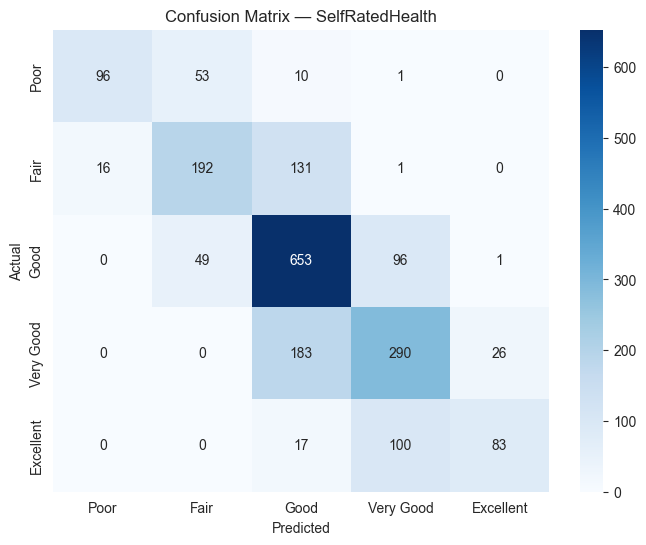

Predictions exactly correct: 65.8%
Predictions off by 1 class: 32.7%
Predictions off by 2+ classes: 1.5%


In [29]:
# Confusion matrix
srh_order = orders['SelfRatedHealth']
cm = confusion_matrix(y_test, y_pred, labels=srh_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=srh_order, yticklabels=srh_order)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix — SelfRatedHealth')
plt.show()

# Since the target is ordinal, also worth checking: how far off are the misclassifications?
# (a Poor predicted as Fair is a smaller mistake than a Poor predicted as Excellent)
true_idx = y_test.map({v: i for i, v in enumerate(srh_order)})
pred_idx = pd.Series(y_pred, index=y_test.index).map({v: i for i, v in enumerate(srh_order)})
off_by = (true_idx - pred_idx).abs()
print(f"Predictions exactly correct: {(off_by == 0).mean():.1%}")
print(f"Predictions off by 1 class: {(off_by == 1).mean():.1%}")
print(f"Predictions off by 2+ classes: {(off_by >= 2).mean():.1%}")

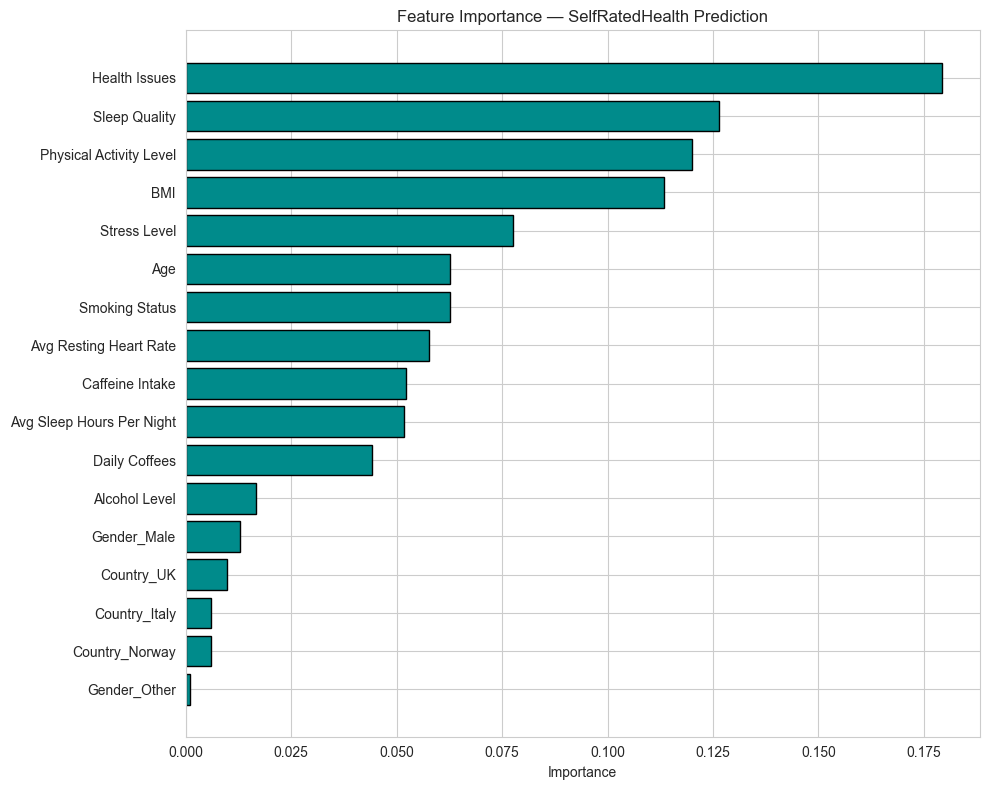

,feature,importance
11,Health Issues,0.179341
10,Sleep Quality,0.126340
6,Physical Activity Level,0.119984
7,BMI,0.113296
5,Stress Level,0.077564
0,Age,0.062767
1,Smoking Status,0.062745
8,Avg Resting Heart Rate,0.057613
4,Caffeine Intake,0.052208
9,Avg Sleep Hours Per Night,0.051742


In [30]:
# Feature importance
importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'], color='darkcyan', edgecolor='black')
plt.gca().invert_yaxis()
plt.xlabel('Importance')
plt.title('Feature Importance — SelfRatedHealth Prediction')
plt.tight_layout()
plt.show()

importance

## 4. Validation Summary

### Data quality issues behave as designed
- Age and BMI anomalies are both exactly recoverable (strip last digit / divide by 10), not collapsed to a sentinel value.
- Missingness on `Avg Sleep Hours Per Night`, `Avg Resting Heart Rate`, and `Stress Level` increases clearly with Age band; `Health Issues` stays flat, and Gender/Country show no strong pattern — matches the intended design.
- The BMI anomalies, despite being only ~0.6% of rows, meaningfully distort the raw BMI↔Activity correlation — worth keeping in mind when reviewing any correlation number from the raw (uncleaned) data.

### EDA patterns show up as intended
- **Coffee habits don't straightforwardly predict health.** Norway and Italy drink the most coffee *and* have the best self-rated health; the UK drinks the least *and* has the worst — objective lifestyle factors (smoking, activity, BMI), not coffee itself, drive the difference.
- **Stress and Sleep Quality are related but not deterministic** — unlike the original source dataset, where Stress Level was a 100% deterministic relabeling of Sleep Quality.
- **Smoking shows a genuine dose-response relationship**: Never > Former > Light Smoker > Heavy Smoker.
- **Daily Coffees ↔ Caffeine Intake is strong but not perfect for a real reason** (decaf/half-caf subgroup), confirmed via the mg-per-cup distribution above, not just asserted.

### ML performance is sane
- ~65% accuracy on the 5-class ordinal target is neither degenerate nor suspiciously perfect (no leakage red flag).
- `Health Issues` is typically the strongest single predictor, but far from deterministic — several other features still contribute.
- Off-by-one errors should dominate the confusion matrix over off-by-two-or-more, reflecting the ordinal, gradually-varying nature of the target.